# GRU_B com múltiplas sementes e seleção do modelo da API

Este notebook congela a arquitetura GRU_B e mede sua estabilidade com as sementes `10, 20, 30, 40 e 50`.

## Objetivos

1. treinar a mesma GRU_B com cinco inicializações;
2. selecionar o melhor checkpoint de cada semente somente pela validação de 2024;
3. calcular média, desvio-padrão, mínimo e máximo das métricas;
4. comparar a distribuição da GRU_B com o HGB TUO determinístico;
5. escolher o modelo da API por regra explícita baseada em 2024;
6. relatar 2025 e 2026 sem usar esses períodos na seleção.

## Arquitetura congelada

- `hidden_size=96`;
- `num_layers=2`;
- `dropout=0.15`;
- `decoder_hidden=192`;
- decodificador compartilhado por horizonte;
- perda MSE padronizada, sem penalização explícita de viés;
- `batch_size=128`, `learning_rate=1e-3`, `weight_decay=1e-5`;
- parada antecipada com paciência 8;
- treino em CUDA e checkpoints compatíveis com CPU.

## 1. Importações, caminhos e configuração congelada

In [1]:
from pathlib import Path
import copy
import json
import platform
import random
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, Dataset

pd.set_option("display.max_columns",120)
pd.set_option("display.width",200)

DIRETORIO_TUO=Path("dados_processados_multivariados/TUO")
DIRETORIO_HGB=Path("resultados_modelagem/hist_gradient_boosting_TUO_48")
DIRETORIO_SAIDA=Path("resultados_modelagem/gru_B_multiplas_sementes")
DIRETORIO_CHECKPOINTS=DIRETORIO_SAIDA/"checkpoints"
DIRETORIO_SAIDA.mkdir(parents=True,exist_ok=True)
DIRETORIO_CHECKPOINTS.mkdir(parents=True,exist_ok=True)

SEMENTES=[10,20,30,40,50]
SPLITS=["treino","validacao","teste","avaliacao_2026"]
BATCH_SIZE=128
MAX_EPOCAS=60
PACIENCIA=8
LEARNING_RATE=1e-3
WEIGHT_DECAY=1e-5
NUM_WORKERS=0

CONFIG_GRU_B={"n_hist":7,"n_fut":4,"hidden_size":96,"num_layers":2,"dropout":0.15,"decoder_hidden":192}
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
USAR_AMP=DEVICE.type=="cuda"

print("Dispositivo de treino:",DEVICE)
if DEVICE.type=="cuda":
 print("GPU:",torch.cuda.get_device_name(0))
 print("VRAM total (GB):",round(torch.cuda.get_device_properties(0).total_memory/1024**3,2))
else:
 print("ATENÇÃO: CUDA não detectada. Interrompa se desejar preservar o protocolo GPU.")
print("Arquitetura congelada:",CONFIG_GRU_B)
print("Sementes:",SEMENTES)

Dispositivo de treino: cuda
GPU: NVIDIA RTX 500 Ada Generation Laptop GPU
VRAM total (GB): 4.0
Arquitetura congelada: {'n_hist': 7, 'n_fut': 4, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.15, 'decoder_hidden': 192}
Sementes: [10, 20, 30, 40, 50]


## 2. Funções de reprodutibilidade e carregamento

In [2]:
def configurar_semente(semente):
 random.seed(semente); np.random.seed(semente); torch.manual_seed(semente)
 if torch.cuda.is_available(): torch.cuda.manual_seed_all(semente)
 torch.backends.cudnn.deterministic=True
 torch.backends.cudnn.benchmark=False

def carregar_npz(caminho):
 with np.load(caminho) as arq: return {k:arq[k] for k in arq.files}

obrigatorios=[DIRETORIO_TUO/f"{s}.npz" for s in SPLITS]+[DIRETORIO_TUO/"scaler_y.joblib",DIRETORIO_TUO/"metadados.json"]
faltantes=[str(x) for x in obrigatorios if not x.exists()]
if faltantes: raise FileNotFoundError("Arquivos ausentes:"+chr(10)+chr(10).join(faltantes))

splits={s:carregar_npz(DIRETORIO_TUO/f"{s}.npz") for s in SPLITS}
scaler_y=joblib.load(DIRETORIO_TUO/"scaler_y.joblib")
with (DIRETORIO_TUO/"metadados.json").open(encoding="utf-8") as f: meta_preparacao=json.load(f)
assert meta_preparacao["configuracao"]=="TUO"
assert meta_preparacao["usa_covariaveis_meteorologicas_futuras"] is False
print(meta_preparacao["contagens"])

{'treino': 84744, 'validacao': 7837, 'teste': 7970, 'avaliacao_2026': 4551}


## 3. Dataset e arquitetura GRU_B congelada

In [3]:
class DatasetMeteorologico(Dataset):
 def __init__(self,split):
  self.xh=torch.from_numpy(split["X_historico"]).float()
  self.xf=torch.from_numpy(split["X_futuro_temporal"]).float()
  self.y=torch.from_numpy(split["y"]).float()
 def __len__(self): return len(self.y)
 def __getitem__(self,i): return self.xh[i],self.xf[i],self.y[i]

class GRUDiretaMultialvo(nn.Module):
 def __init__(self,n_hist=7,n_fut=4,hidden_size=96,num_layers=2,dropout=0.15,decoder_hidden=192):
  super().__init__()
  self.config=dict(n_hist=n_hist,n_fut=n_fut,hidden_size=hidden_size,num_layers=num_layers,dropout=dropout,decoder_hidden=decoder_hidden)
  self.gru=nn.GRU(input_size=n_hist,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,dropout=dropout if num_layers>1 else 0.0)
  self.decoder=nn.Sequential(nn.Linear(hidden_size+n_fut,decoder_hidden),nn.ReLU(),nn.Dropout(dropout),nn.Linear(decoder_hidden,2))
 def forward(self,x_hist,x_fut):
  _,h=self.gru(x_hist)
  contexto=h[-1].unsqueeze(1).expand(-1,x_fut.size(1),-1)
  return self.decoder(torch.cat([contexto,x_fut],dim=-1))

datasets={s:DatasetMeteorologico(splits[s]) for s in SPLITS}
modelo_teste=GRUDiretaMultialvo(**CONFIG_GRU_B)
print("Parâmetros treináveis:",sum(p.numel() for p in modelo_teste.parameters() if p.requires_grad))
del modelo_teste

Parâmetros treináveis: 105890


## 4. Funções de treino, inferência e métricas

In [4]:
LOSS_FN=nn.MSELoss()

def criar_loaders(semente):
 g=torch.Generator(); g.manual_seed(semente)
 return {
  "treino":DataLoader(datasets["treino"],batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda",generator=g),
  "validacao":DataLoader(datasets["validacao"],batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda"),
  "teste":DataLoader(datasets["teste"],batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda"),
  "avaliacao_2026":DataLoader(datasets["avaliacao_2026"],batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda"),
 }

def executar_epoca(modelo,loader,otimizador=None,scaler_amp=None):
 treino=otimizador is not None; modelo.train(treino); soma=0.0; n=0
 for xh,xf,yy in loader:
  xh=xh.to(DEVICE,non_blocking=True); xf=xf.to(DEVICE,non_blocking=True); yy=yy.to(DEVICE,non_blocking=True)
  if treino: otimizador.zero_grad(set_to_none=True)
  with torch.autocast(device_type=DEVICE.type,dtype=torch.float16,enabled=USAR_AMP):
   pred=modelo(xh,xf); loss=LOSS_FN(pred,yy)
  if treino:
   scaler_amp.scale(loss).backward(); scaler_amp.unscale_(otimizador)
   torch.nn.utils.clip_grad_norm_(modelo.parameters(),1.0)
   scaler_amp.step(otimizador); scaler_amp.update()
  soma+=loss.item()*len(yy); n+=len(yy)
 return soma/n

@torch.no_grad()
def prever(modelo,loader):
 modelo.eval(); reais=[]; preds=[]
 for xh,xf,yy in loader:
  xh=xh.to(DEVICE,non_blocking=True); xf=xf.to(DEVICE,non_blocking=True)
  with torch.autocast(device_type=DEVICE.type,dtype=torch.float16,enabled=USAR_AMP): pred=modelo(xh,xf)
  reais.append(yy.numpy()); preds.append(pred.float().cpu().numpy())
 return np.concatenate(reais),np.concatenate(preds)

def inverter(y_norm):
 forma=y_norm.shape
 return scaler_y.inverse_transform(y_norm.reshape(-1,2)).reshape(forma)

def calcular_metricas(y_real,y_pred,semente,split):
 linhas=[]
 for h in range(24):
  for j,(alvo,unidade) in {0:("temperatura_c","°C"),1:("umidade_pct","p.p.")}.items():
   r=y_real[:,h,j]; p=y_pred[:,h,j]
   linhas.append({"semente":semente,"split":split,"horizonte_horas":h+1,"alvo":alvo,"unidade":unidade,
    "mae":mean_absolute_error(r,p),"rmse":mean_squared_error(r,p)**0.5,"vies":float(np.mean(p-r)),"n":len(r)})
 return pd.DataFrame(linhas)

## 5. Treinamento das cinco sementes

Cada semente possui parada antecipada própria em 2024. O melhor estado é salvo imediatamente em CPU. Se um checkpoint já existir, ele será reutilizado.

In [5]:
REUTILIZAR_CHECKPOINTS=True
historicos=[]; resumo_treino=[]; metricas_sementes=[]

for semente in SEMENTES:
 print(chr(10)+"="*78); print("SEMENTE",semente); print("="*78)
 configurar_semente(semente); loaders=criar_loaders(semente)
 caminho_ckpt=DIRETORIO_CHECKPOINTS/f"gru_B_semente_{semente}.pt"
 modelo=GRUDiretaMultialvo(**CONFIG_GRU_B).to(DEVICE)

 if REUTILIZAR_CHECKPOINTS and caminho_ckpt.exists():
  ckpt=torch.load(caminho_ckpt,map_location=DEVICE,weights_only=False)
  modelo.load_state_dict(ckpt["state_dict"]); melhor=ckpt["melhor_loss_validacao"]; epocas=ckpt["epocas_executadas"]; tempo=0.0; pico=0.0
  print("Checkpoint carregado:",caminho_ckpt)
 else:
  opt=torch.optim.AdamW(modelo.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
  scaler_amp=torch.amp.GradScaler("cuda",enabled=USAR_AMP)
  melhor=np.inf; melhor_estado=None; sem_melhora=0; t0=time.perf_counter(); hist=[]
  if DEVICE.type=="cuda": torch.cuda.reset_peak_memory_stats()
  for epoca in range(1,MAX_EPOCAS+1):
   tr=executar_epoca(modelo,loaders["treino"],opt,scaler_amp)
   va=executar_epoca(modelo,loaders["validacao"])
   hist.append({"semente":semente,"epoca":epoca,"loss_treino_padronizada":tr,"loss_validacao_padronizada":va})
   print(f"época {epoca:02d} | treino={tr:.6f} | validação={va:.6f}")
   if va<melhor-1e-6:
    melhor=va; melhor_estado=copy.deepcopy(modelo.state_dict()); sem_melhora=0
   else: sem_melhora+=1
   if sem_melhora>=PACIENCIA: print("Parada antecipada."); break
  historicos.extend(hist); modelo.load_state_dict(melhor_estado); epocas=len(hist); tempo=time.perf_counter()-t0
  pico=torch.cuda.max_memory_allocated()/1024**3 if DEVICE.type=="cuda" else 0.0
  estado_cpu={k:v.detach().cpu() for k,v in modelo.state_dict().items()}
  torch.save({"state_dict":estado_cpu,"model_config":modelo.config,"semente":semente,"melhor_loss_validacao":melhor,
              "epocas_executadas":epocas,"usa_covariaveis_meteorologicas_futuras":False},caminho_ckpt)

 resumo_treino.append({"semente":semente,"melhor_loss_validacao_padronizada":melhor,"epocas_executadas":epocas,
                       "tempo_segundos":tempo,"pico_vram_gb":pico})
 for split in ["validacao","teste","avaliacao_2026"]:
  yrn,ypn=prever(modelo,loaders[split]); yr=inverter(yrn); yp=inverter(ypn)
  metricas_sementes.append(calcular_metricas(yr,yp,semente,split))
  np.savez_compressed(DIRETORIO_SAIDA/f"previsoes_semente_{semente}_{split}.npz",y_real=yr.astype(np.float32),y_pred=yp.astype(np.float32),inicio_previsao=splits[split]["inicio_previsao"])
 del modelo
 if DEVICE.type=="cuda": torch.cuda.empty_cache()

resumo_treino=pd.DataFrame(resumo_treino)
metricas_sementes=pd.concat(metricas_sementes,ignore_index=True)
display(resumo_treino)


SEMENTE 10
época 01 | treino=0.266550 | validação=0.260616
época 02 | treino=0.224300 | validação=0.251424
época 03 | treino=0.218105 | validação=0.246811
época 04 | treino=0.212787 | validação=0.252942
época 05 | treino=0.208347 | validação=0.256254
época 06 | treino=0.204141 | validação=0.246721
época 07 | treino=0.198590 | validação=0.253965
época 08 | treino=0.192365 | validação=0.248362
época 09 | treino=0.184285 | validação=0.250680
época 10 | treino=0.176997 | validação=0.270332
época 11 | treino=0.169279 | validação=0.268861
época 12 | treino=0.160612 | validação=0.283245
época 13 | treino=0.153666 | validação=0.277576
época 14 | treino=0.146066 | validação=0.299834
Parada antecipada.

SEMENTE 20
época 01 | treino=0.262841 | validação=0.259752
época 02 | treino=0.223587 | validação=0.247432
época 03 | treino=0.217652 | validação=0.247731
época 04 | treino=0.213620 | validação=0.246625
época 05 | treino=0.209088 | validação=0.242749
época 06 | treino=0.204763 | validação=0.2517

,semente,melhor_loss_validacao_padronizada,epocas_executadas,tempo_segundos,pico_vram_gb
0,10,0.246721,14,115.440188,0.039223
1,20,0.242749,13,105.693831,0.039223
2,30,0.239669,13,105.037082,0.039223
3,40,0.242779,15,123.912355,0.039223
4,50,0.240545,13,102.352255,0.039223


## 6. Métricas globais por semente

In [6]:
globais=[]
for (semente,split,alvo,unidade),g in metricas_sementes.groupby(["semente","split","alvo","unidade"]):
 caminho=DIRETORIO_SAIDA/f"previsoes_semente_{semente}_{split}.npz"
 with np.load(caminho) as arq:
  j=0 if alvo=="temperatura_c" else 1
  real=arq["y_real"][:,:,j].ravel(); pred=arq["y_pred"][:,:,j].ravel()
 globais.append({"semente":semente,"split":split,"alvo":alvo,"unidade":unidade,
  "mae_global_1a24":mean_absolute_error(real,pred),"rmse_global_1a24":mean_squared_error(real,pred)**0.5,
  "vies_global_1a24":float(np.mean(pred-real)),"n_previsoes":len(real)})
metricas_globais_semente=pd.DataFrame(globais)
display(metricas_globais_semente.sort_values(["split","alvo","semente"]).reset_index(drop=True))

,semente,split,alvo,unidade,mae_global_1a24,rmse_global_1a24,vies_global_1a24,n_previsoes
0,10,avaliacao_2026,temperatura_c,°C,1.350151,1.884818,0.038359,109224
1,20,avaliacao_2026,temperatura_c,°C,1.356390,1.916535,0.042788,109224
2,30,avaliacao_2026,temperatura_c,°C,1.356928,1.915357,0.171428,109224
3,40,avaliacao_2026,temperatura_c,°C,1.355812,1.897846,0.015056,109224
4,50,avaliacao_2026,temperatura_c,°C,1.348069,1.919411,0.217599,109224
5,10,avaliacao_2026,umidade_pct,p.p.,7.082170,9.770790,-0.837743,109224
6,20,avaliacao_2026,umidade_pct,p.p.,7.006707,9.857013,-0.893833,109224
7,30,avaliacao_2026,umidade_pct,p.p.,7.031099,9.911800,-1.783634,109224
8,40,avaliacao_2026,umidade_pct,p.p.,6.979373,9.879460,-1.670717,109224
9,50,avaliacao_2026,umidade_pct,p.p.,6.996219,9.910888,-1.592806,109224


## 7. Média, desvio-padrão e estabilidade

In [7]:
agregadas=(metricas_globais_semente.groupby(["split","alvo","unidade"])
 .agg(mae_medio=("mae_global_1a24","mean"),mae_dp=("mae_global_1a24","std"),mae_min=("mae_global_1a24","min"),mae_max=("mae_global_1a24","max"),
      rmse_medio=("rmse_global_1a24","mean"),rmse_dp=("rmse_global_1a24","std"),
      vies_medio=("vies_global_1a24","mean"),vies_dp=("vies_global_1a24","std"),vies_abs_medio=("vies_global_1a24",lambda x:np.mean(np.abs(x))))
 .reset_index())
agregadas["cv_mae_pct"]=100*agregadas.mae_dp/agregadas.mae_medio
display(agregadas)

,split,alvo,unidade,mae_medio,mae_dp,mae_min,mae_max,rmse_medio,rmse_dp,vies_medio,vies_dp,vies_abs_medio,cv_mae_pct
0,avaliacao_2026,temperatura_c,°C,1.353470,0.004067,1.348069,1.356928,1.906793,0.014920,0.097046,0.091072,0.097046,0.300462
1,avaliacao_2026,umidade_pct,p.p.,7.019114,0.039928,6.979373,7.082170,9.865990,0.057964,-1.355747,0.452819,1.355747,0.568851
2,teste,temperatura_c,°C,1.556485,0.012861,1.540044,1.575561,2.249133,0.019282,0.171274,0.124084,0.171274,0.826316
3,teste,umidade_pct,p.p.,7.938788,0.046875,7.893811,8.014743,11.355639,0.091404,-1.057146,0.557939,1.057146,0.590457
4,validacao,temperatura_c,°C,1.546968,0.020240,1.521997,1.574560,2.150231,0.007328,-0.077098,0.124112,0.114402,1.308356
5,validacao,umidade_pct,p.p.,7.868989,0.159194,7.687659,8.100855,10.830425,0.077737,0.117177,0.599057,0.457281,2.023055


## 8. Referência HGB e comparação por semente

In [8]:
caminho_hgb=DIRETORIO_HGB/"metricas_globais_48.csv"
if not caminho_hgb.exists(): raise FileNotFoundError(f"Métricas HGB não encontradas: {caminho_hgb}")
hgb=pd.read_csv(caminho_hgb,encoding="utf-8-sig")
hgb=hgb[hgb.modelo=="hgb"].copy()

comparacao=[]
for _,r in metricas_globais_semente.iterrows():
 ref=hgb[(hgb.split==r.split)&(hgb.alvo==r.alvo)].iloc[0]
 comparacao.append({"semente":r.semente,"split":r.split,"alvo":r.alvo,"unidade":r.unidade,
  "mae_gru":r.mae_global_1a24,"mae_hgb":ref.mae_global_1a24,"ganho_mae_gru_pct":100*(ref.mae_global_1a24-r.mae_global_1a24)/ref.mae_global_1a24,
  "rmse_gru":r.rmse_global_1a24,"rmse_hgb":ref.rmse_global_1a24,"ganho_rmse_gru_pct":100*(ref.rmse_global_1a24-r.rmse_global_1a24)/ref.rmse_global_1a24,
  "vies_gru":r.vies_global_1a24,"vies_hgb":ref.vies_global_1a24})
comparacao_sementes=pd.DataFrame(comparacao)
resumo_vs_hgb=(comparacao_sementes.groupby(["split","alvo","unidade"])
 .agg(ganho_mae_medio_pct=("ganho_mae_gru_pct","mean"),ganho_mae_dp_pct=("ganho_mae_gru_pct","std"),
      sementes_mae_melhor_hgb=("ganho_mae_gru_pct",lambda x:int((x>0).sum())),
      ganho_rmse_medio_pct=("ganho_rmse_gru_pct","mean"),sementes_rmse_melhor_hgb=("ganho_rmse_gru_pct",lambda x:int((x>0).sum())))
 .reset_index())
display(resumo_vs_hgb)

,split,alvo,unidade,ganho_mae_medio_pct,ganho_mae_dp_pct,sementes_mae_melhor_hgb,ganho_rmse_medio_pct,sementes_rmse_melhor_hgb
0,avaliacao_2026,temperatura_c,°C,2.385563,0.293294,5,2.015595,5
1,avaliacao_2026,umidade_pct,p.p.,0.342765,0.566901,4,0.577278,5
2,teste,temperatura_c,°C,1.294355,0.815620,5,0.507259,4
3,teste,umidade_pct,p.p.,0.509022,0.587452,4,0.785841,4
4,validacao,temperatura_c,°C,4.128350,1.254342,5,3.014629,5
5,validacao,umidade_pct,p.p.,1.260770,1.997549,4,1.654147,5


## 9. Regra explícita para escolher o modelo da API

A decisão usa somente 2024. A GRU será escolhida se:

1. o MAE médio das cinco sementes superar o HGB nos dois alvos;
2. pelo menos quatro das cinco sementes superarem o HGB em MAE para cada alvo;
3. o coeficiente de variação do MAE for inferior a 2% nos dois alvos;
4. o viés absoluto médio da umidade não exceder o do HGB em mais de 1 ponto percentual.

Se qualquer condição falhar, o HGB será escolhido por estabilidade, simplicidade operacional e inferência determinística em CPU.

In [9]:
val=resumo_vs_hgb[resumo_vs_hgb.split=="validacao"].set_index("alvo")
est=agregadas[agregadas.split=="validacao"].set_index("alvo")
hgb_val=hgb[hgb.split=="validacao"].set_index("alvo")

cond_ganho=(val.ganho_mae_medio_pct>0).all()
cond_sementes=(val.sementes_mae_melhor_hgb>=4).all()
cond_estabilidade=(est.cv_mae_pct<2.0).all()
cond_vies_umidade=est.loc["umidade_pct","vies_abs_medio"] <= abs(hgb_val.loc["umidade_pct","vies_global_1a24"])+1.0
MODELO_API="GRU_B" if cond_ganho and cond_sementes and cond_estabilidade and cond_vies_umidade else "HGB_TUO"

print("Ganho médio nos dois alvos:",cond_ganho)
print("Pelo menos 4/5 sementes melhores nos dois alvos:",cond_sementes)
print("CV do MAE inferior a 2%:",cond_estabilidade)
print("Viés de umidade dentro da tolerância:",cond_vies_umidade)
print("MODELO SELECIONADO PARA A API:",MODELO_API)

Ganho médio nos dois alvos: True
Pelo menos 4/5 sementes melhores nos dois alvos: True
CV do MAE inferior a 2%: False
Viés de umidade dentro da tolerância: True
MODELO SELECIONADO PARA A API: HGB_TUO


## 10. Gráficos de estabilidade

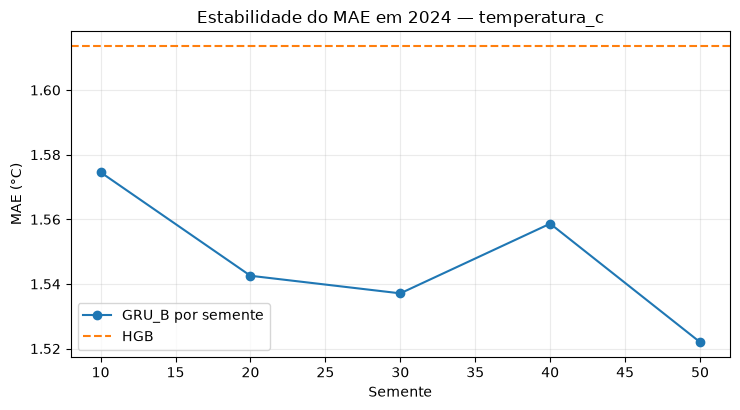

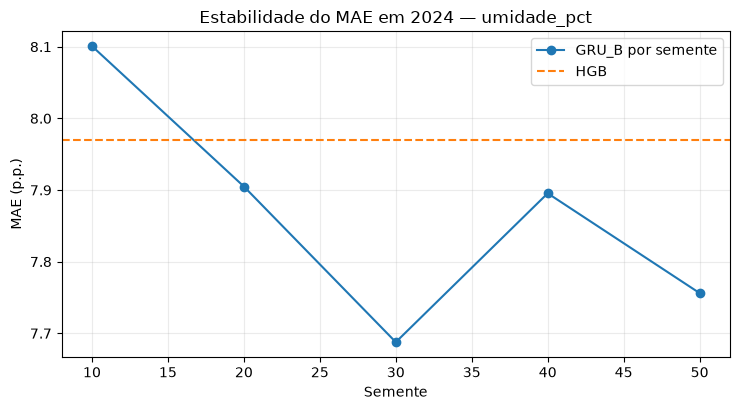

In [10]:
for alvo in ["temperatura_c","umidade_pct"]:
 d=metricas_globais_semente[(metricas_globais_semente.split=="validacao")&(metricas_globais_semente.alvo==alvo)].sort_values("semente")
 ref=hgb_val.loc[alvo,"mae_global_1a24"]
 fig,ax=plt.subplots(figsize=(7.5,4.2))
 ax.plot(d.semente,d.mae_global_1a24,marker="o",label="GRU_B por semente")
 ax.axhline(ref,color="tab:orange",linestyle="--",label="HGB")
 ax.set(title=f"Estabilidade do MAE em 2024 — {alvo}",xlabel="Semente",ylabel=f"MAE ({d.unidade.iloc[0]})")
 ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

## 11. Checkpoint representativo para a API

In [11]:
# Se a GRU vencer, usa-se a semente de menor MAE padronizado médio em 2024.
val_seed=metricas_globais_semente[metricas_globais_semente.split=="validacao"].copy()
linhas=[]
for semente,g in val_seed.groupby("semente"):
 mt=g[g.alvo=="temperatura_c"].mae_global_1a24.iloc[0]/scaler_y.scale_[0]
 mu=g[g.alvo=="umidade_pct"].mae_global_1a24.iloc[0]/scaler_y.scale_[1]
 linhas.append({"semente":semente,"criterio_mae_padronizado_medio":(mt+mu)/2})
ranking_sementes=pd.DataFrame(linhas).sort_values("criterio_mae_padronizado_medio").reset_index(drop=True)
SEMENTE_REPRESENTATIVA=int(ranking_sementes.loc[0,"semente"])

if MODELO_API=="GRU_B":
 origem=DIRETORIO_CHECKPOINTS/f"gru_B_semente_{SEMENTE_REPRESENTATIVA}.pt"
 destino=DIRETORIO_SAIDA/"modelo_api_gru_B_cpu.pt"
 ckpt=torch.load(origem,map_location="cpu",weights_only=False)
 ckpt["semente_representativa"]=SEMENTE_REPRESENTATIVA
 ckpt["criterio_selecao_semente"]="menor MAE padronizado médio em 2024 após seleção da família GRU por estabilidade"
 ckpt["inferencia"]="cpu"
 torch.save(ckpt,destino)
 print("Checkpoint da API:",destino)
else:
 print("HGB selecionado. Usar o pacote existente:",DIRETORIO_HGB/"pacote_hgb_TUO_48_api.joblib")
print("Semente representativa da GRU:",SEMENTE_REPRESENTATIVA)
display(ranking_sementes)

HGB selecionado. Usar o pacote existente: resultados_modelagem\hist_gradient_boosting_TUO_48\pacote_hgb_TUO_48_api.joblib
Semente representativa da GRU: 30


,semente,criterio_mae_padronizado_medio
0,30,0.348320
1,50,0.348525
2,20,0.354340
3,40,0.355723
4,10,0.362499


## 12. Salvamento e verificação final

In [13]:
pd.DataFrame(historicos).to_csv(DIRETORIO_SAIDA/"historico_treinamento_sementes.csv",index=False,encoding="utf-8-sig")
resumo_treino.to_csv(DIRETORIO_SAIDA/"resumo_treinamento_sementes.csv",index=False,encoding="utf-8-sig")
metricas_sementes.to_csv(DIRETORIO_SAIDA/"metricas_por_horizonte_sementes.csv",index=False,encoding="utf-8-sig")
metricas_globais_semente.to_csv(DIRETORIO_SAIDA/"metricas_globais_por_semente.csv",index=False,encoding="utf-8-sig")
agregadas.to_csv(DIRETORIO_SAIDA/"metricas_agregadas_sementes.csv",index=False,encoding="utf-8-sig")
comparacao_sementes.to_csv(DIRETORIO_SAIDA/"comparacao_gru_hgb_por_semente.csv",index=False,encoding="utf-8-sig")
resumo_vs_hgb.to_csv(DIRETORIO_SAIDA/"resumo_gru_vs_hgb.csv",index=False,encoding="utf-8-sig")
ranking_sementes.to_csv(DIRETORIO_SAIDA/"ranking_sementes_validacao_2024.csv",index=False,encoding="utf-8-sig")
meta={"arquitetura":"GRU_B congelada","configuracao":"TUO","sementes":SEMENTES,"modelo_api":MODELO_API,
 "semente_representativa_gru":SEMENTE_REPRESENTATIVA,"regra_selecao":"somente validação 2024",
 "treino_dispositivo":str(DEVICE),"inferencia":"CPU","usa_covariaveis_meteorologicas_futuras":False,
 "config_gru_b":CONFIG_GRU_B,"versoes":{"python":sys.version.split()[0],"pytorch":torch.__version__,"numpy":np.__version__,"plataforma":platform.platform()}}
with (DIRETORIO_SAIDA/"decisao_modelo_api.json").open("w",encoding="utf-8") as f: json.dump(meta,f,ensure_ascii=False,indent=2)
assert len(metricas_globais_semente.semente.unique())==5
assert np.isfinite(metricas_globais_semente[["mae_global_1a24","rmse_global_1a24","vies_global_1a24"]].to_numpy()).all()
assert meta["usa_covariaveis_meteorologicas_futuras"] is False
print("VERIFICAÇÃO FINAL: OK")
print("MODELO PARA A API:",MODELO_API)
print(f"Semente representativa GRU: {SEMENTE_REPRESENTATIVA}")

VERIFICAÇÃO FINAL: OK
MODELO PARA A API: HGB_TUO
Semente representativa GRU: 30


## Encerramento

Após revisar a decisão, a próxima etapa será implementar a camada de alertas mínimos:

- temperatura elevada nas próximas 24 horas;
- persistência de umidade elevada nas condições meteorológicas externas;
- chuva prevista proveniente da API externa.

Os limiares agronômicos permanecerão em configuração auditável e vinculados às respectivas fontes.